In [3]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.mixture import GaussianMixture
from statsmodels.stats.multitest import multipletests
import scipy
from scipy.stats import f_oneway


In [110]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)
greens = sns.blend_palette(['#c8e9c1', '#75c477','#238b45'  ], as_cmap = True)
purples = sns.blend_palette(['#dadaeb', '#9e9bc8','#6a51a3' ], as_cmap = True)
oranges = sns.blend_palette(['#fdd1a3', '#fd8e3d','#d94801' ], as_cmap = True)

In [45]:
#load GTF
gtffile= pd.read_csv('annotations_cleaned.gtf', index_col=None, skiprows=5, header=None, low_memory=False, delimiter="\t")
gtffile

,0,1,2,3,4,5,6,7,8
0,1,havana,gene,3073253,3074322,.,+,.,"gene_id ""ENSMUSG00000102693""; gene_version ""1""..."
1,1,havana,transcript,3073253,3074322,.,+,.,"gene_id ""ENSMUSG00000102693""; gene_version ""1""..."
2,1,havana,exon,3073253,3074322,.,+,.,"gene_id ""ENSMUSG00000102693""; gene_version ""1""..."
3,1,ensembl,gene,3102016,3102125,.,+,.,"gene_id ""ENSMUSG00000064842""; gene_version ""1""..."
4,1,ensembl,transcript,3102016,3102125,.,+,.,"gene_id ""ENSMUSG00000064842""; gene_version ""1""..."
...,...,...,...,...,...,...,...,...,...
1851422,JH584295.1,ensembl,CDS,708,752,.,-,2,"gene_id ""ENSMUSG00000095742""; gene_version ""1""..."
1851423,JH584295.1,ensembl,exon,565,633,.,-,.,"gene_id ""ENSMUSG00000095742""; gene_version ""1""..."
1851424,JH584295.1,ensembl,CDS,565,633,.,-,2,"gene_id ""ENSMUSG00000095742""; gene_version ""1""..."
1851425,JH584295.1,ensembl,exon,66,109,.,-,.,"gene_id ""ENSMUSG00000095742""; gene_version ""1""..."


In [46]:
gtffile.columns=("chr","database","type","start","stop","unkown","strand","CDS","details")
genes2=gtffile[gtffile['type']=='gene']
step1=genes2["details"].str.split(';', 0, expand=True)
step2=step1[2].str.split('"', 0, expand=True)
genes2["genename"]=step2[1]
step3=step1[0].str.split('"', 0, expand=True)
genes2["geneID"]=step3[1]
step5=step1[4].str.split('"', 0, expand=True)
genes2["biotype"]=step5[1]


genes2=genes2[genes2['genename']!='ensembl']
#genes=genes[~(genes['database']=='havana')]
#genes=genes[genes['biotype']=='protein_coding']

/home/p.zeller_cbs-niob.local/miniconda3/envs/TChIC_env/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
/home/p.zeller_cbs-niob.local/miniconda3/envs/TChIC_env/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys
/home/p.zeller_cbs-niob.local/miniconda3/envs/TChIC_env/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

In [47]:
#to get main isoforms
genes2_plus=genes2[genes2['strand']=='+'].sort_values(by='start',ascending=True)
genes2_minus=genes2[genes2['strand']=='-'].sort_values(by='start', ascending=False)
plus2=genes2_plus.drop_duplicates(subset = ['genename'], keep = 'first').reset_index(drop = True)
minus2=genes2_minus.drop_duplicates(subset = ['genename'], keep = 'first').reset_index(drop = True)



In [48]:
gtffile.columns=("chr","database","type","start","stop","unkown","strand","CDS","details")
genes=gtffile[gtffile['type']=='transcript']
step1=genes["details"].str.split(';', 0, expand=True)
step2=step1[4].str.split('"', 0, expand=True)
genes["genename"]=step2[1]
step3=step1[0].str.split('"', 0, expand=True)
genes["geneID"]=step3[1]
step5=step1[6].str.split('"', 0, expand=True)
genes["biotype"]=step5[1]

step7=step1[3].str.split('"', 0, expand=True)
genes["transcript_number"]=step7[1]
genes=genes[genes['genename']!='ensembl']
#genes=genes[~(genes['database']=='havana')]
#genes=genes[genes['biotype']=='protein_coding']
genes

/home/p.zeller_cbs-niob.local/miniconda3/envs/TChIC_env/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """
/home/p.zeller_cbs-niob.local/miniconda3/envs/TChIC_env/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys
/home/p.zeller_cbs-niob.local/miniconda3/envs/TChIC_env/lib/python3.7/site-packages/ipykernel_launcher.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

,chr,database,type,start,stop,unkown,strand,CDS,details,genename,geneID,biotype,transcript_number
1,1,havana,transcript,3073253,3074322,.,+,.,"gene_id ""ENSMUSG00000102693""; gene_version ""1""...",4933401J01Rik,ENSMUSG00000102693,TEC,1
4,1,ensembl,transcript,3102016,3102125,.,+,.,"gene_id ""ENSMUSG00000064842""; gene_version ""1""...",Gm26206,ENSMUSG00000064842,snRNA,1
7,1,havana,transcript,3205901,3216344,.,-,.,"gene_id ""ENSMUSG00000051951""; gene_version ""5""...",Xkr4,ENSMUSG00000051951,protein_coding,1
10,1,havana,transcript,3206523,3215632,.,-,.,"gene_id ""ENSMUSG00000051951""; gene_version ""5""...",Xkr4,ENSMUSG00000051951,protein_coding,1
13,1,ensembl_havana,transcript,3214482,3671498,.,-,.,"gene_id ""ENSMUSG00000051951""; gene_version ""5""...",Xkr4,ENSMUSG00000051951,protein_coding,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1851353,JH584292.1,ensembl,transcript,3536,11935,.,+,.,"gene_id ""ENSMUSG00000096730""; gene_version ""7""...",Vmn2r122,ENSMUSG00000096730,protein_coding,13
1851368,JH584292.1,ensembl,transcript,3536,11935,.,+,.,"gene_id ""ENSMUSG00000096730""; gene_version ""7""...",Vmn2r122,ENSMUSG00000096730,protein_coding,1
1851383,JH584292.1,ensembl,transcript,3539,11606,.,+,.,"gene_id ""ENSMUSG00000096730""; gene_version ""7""...",Vmn2r122,ENSMUSG00000096730,protein_coding,4
1851394,JH584292.1,ensembl,transcript,3573,11934,.,+,.,"gene_id ""ENSMUSG00000096730""; gene_version ""7""...",Vmn2r122,ENSMUSG00000096730,protein_coding,7


In [6]:
genes[genes['genename']=='Wnk3']

,chr,database,type,start,stop,unkown,strand,CDS,details,genename,geneID,biotype,transcript_number
321170,X,havana,transcript,151198078,151315186,.,+,.,"gene_id ""ENSMUSG00000041245""; gene_version ""13...",Wnk3,ENSMUSG00000041245,protein_coding,7
321219,X,havana,transcript,151198078,151315186,.,+,.,"gene_id ""ENSMUSG00000041245""; gene_version ""13...",Wnk3,ENSMUSG00000041245,protein_coding,7
321268,X,havana,transcript,151198140,151315128,.,+,.,"gene_id ""ENSMUSG00000041245""; gene_version ""13...",Wnk3,ENSMUSG00000041245,protein_coding,7
321316,X,ensembl,transcript,151198140,151318309,.,+,.,"gene_id ""ENSMUSG00000041245""; gene_version ""13...",Wnk3,ENSMUSG00000041245,protein_coding,4
321364,X,havana,transcript,151207750,151226664,.,+,.,"gene_id ""ENSMUSG00000041245""; gene_version ""13...",Wnk3,ENSMUSG00000041245,protein_coding,1
321369,X,havana,transcript,151294520,151320152,.,+,.,"gene_id ""ENSMUSG00000041245""; gene_version ""13...",Wnk3,ENSMUSG00000041245,protein_coding,1


In [49]:
#manully add and remove TSS
genes=pd.concat([genes,pd.DataFrame({"chr":5,"database":'new','type':'transcript','start':8712500,"stop":8715000,'unkown':'.','strand':'+','details':'','genename':'Abcb1a','geneID':'ENSMUSG00000040584','biotype':'protein_coding','transcript_number':'5'}, index=[0])])
genes=pd.concat([genes,pd.DataFrame({"chr":9,"database":'new','type':'transcript','start':67633263,"stop":67633263,'unkown':'.','strand':'-','details':'','genename':'Tln2','geneID':'ENSMUSG00000052698','biotype':'protein_coding','transcript_number':'1'}, index=[0])])
genes=pd.concat([genes,pd.DataFrame({"chr":9,"database":'new','type':'transcript','start':32032242,"stop":32032242,'unkown':'.','strand':'+','details':'','genename':'Arhgap32','geneID':'ENSMUSG00000041444','biotype':'protein_coding','transcript_number':'1'}, index=[0])])
genes=pd.concat([genes,pd.DataFrame({"chr":12,"database":'new','type':'transcript','start':117155115,"stop":117155115,'unkown':'.','strand':'+','details':'','genename':'Ptprn2','geneID':'ENSMUSG00000056553','biotype':'protein_coding','transcript_number':'1'}, index=[0])])
genes=pd.concat([genes,pd.DataFrame({"chr":'X',"database":'new','type':'transcript','start':151169972,"stop":151169972,'unkown':'.','strand':'+','details':'','genename':'Wnk3','geneID':'ENSMUSG00000041245','biotype':'protein_coding','transcript_number':'1'}, index=[0])])


genes_to_remove={'Gm49797','Ttn','Mirg','Gucy1b2'}
genes=genes[~genes['genename'].isin(genes_to_remove)]



In [50]:
genes=genes[genes['biotype'].isin({'protein_coding','lncRNA'})]

In [51]:
#to get main starting isoforms
genes_plus=genes[genes['strand']=='+'].sort_values(by='start',ascending=True)
genes_minus=genes[genes['strand']=='-'].sort_values(by='start', ascending=False)
plus=genes_plus.sort_values(by='transcript_number').drop_duplicates(subset = ['genename', 'start'], keep = 'first').reset_index(drop = True)
minus=genes_minus.sort_values(by='transcript_number').drop_duplicates(subset = ['genename', 'stop'], keep = 'first').reset_index(drop = True)


In [52]:
tmp4=pd.DataFrame()
for g in plus['genename'].unique():
    tmp=plus[plus['genename']==g]
    tmp=tmp.sort_values(by='start',ascending=True)
    tmp2=pd.DataFrame()
    tmp2[0]=tmp.iloc[0]
    tmp2=tmp2.T
    for ex in tmp.index:
        if (((tmp.loc[ex,'start']-tmp2.iloc[-1]['start'])>5000)):
            tmp3=tmp.loc[ex]
            tmp2=tmp2.append(tmp3)
    tmp2['genename2']=tmp2['genename']+':'+(tmp2.reset_index(drop=True).index+1).astype(str)
    tmp4=tmp4.append(tmp2)
plus=tmp4.copy()


tmp4=pd.DataFrame()
for g in minus['genename'].unique():
    tmp=minus[minus['genename']==g]
    tmp=tmp.sort_values(by='stop',ascending=False)
    tmp2=pd.DataFrame()
    tmp2[0]=tmp.iloc[0]
    tmp2=tmp2.T
    for ex in tmp.index:
        if (((tmp2.iloc[-1]['stop']-tmp.loc[ex,'stop'])>5000)):
            tmp3=tmp.loc[ex]
            tmp2=tmp2.append(tmp3)
    tmp2['genename2']=tmp2['genename']+':'+(tmp2.reset_index(drop=True).index+1).astype(str)
    tmp4=tmp4.append(tmp2)
minus=tmp4.copy()

In [53]:
#identify main annotated gene version
plus['dist_main']=10000
plus['prom_type']='other'
plus['prom_num_an']=0
for g in plus['genename'].unique():
    #print(g)
    plus.loc[plus['genename']==g,'dist_main']=np.absolute([x - plus2.loc[plus2['genename']==g,'start'] for x in plus.loc[plus['genename']==g,'start']])
    plus.loc[plus.loc[plus['genename']==g].sort_values(by='dist_main').index[0],'prom_type']='main_an'
    plus.loc[plus['genename']==g,'prom_num_an']=len(plus.loc[plus['genename']==g,'stop'])

In [54]:
#identify main annotated gene version
minus['dist_main']=10000
minus['prom_type']='other'
minus['prom_num_an']=0
for g in minus['genename'].unique():
    #print(g)
    minus.loc[minus['genename']==g,'dist_main']=np.absolute([x - minus2.loc[minus2['genename']==g,'stop'] for x in minus.loc[minus['genename']==g,'stop']])
    minus.loc[minus.loc[minus['genename']==g].sort_values(by='dist_main').index[0],'prom_type']='main_an'
    minus.loc[minus['genename']==g,'prom_num_an']=len(minus.loc[minus['genename']==g,'stop'])


In [65]:
#identify and remove promotors overlaqpping gene end
plus2copy=plus2[['genename','stop']].copy()
plus2copy.columns=['genename','geneend']
plus=plus.merge(plus2copy, how='left', left_on='genename', right_on='genename')
plus['enddist']=plus['geneend']-plus['start']

In [66]:
promstoremveplus=plus.loc[((plus['enddist']<7500)&(plus['prom_type']=='other')),'genename2']

In [67]:
minus2copy=minus2[['genename','start']].copy()
minus2copy.columns=['genename','geneend']
minus=minus.merge(minus2copy, how='left', left_on='genename', right_on='genename')
minus['enddist']=minus['stop']-minus['geneend']

In [68]:
promstoremveminus=minus.loc[((minus['enddist']<7500)&(minus['prom_type']=='other')),'genename2']

In [69]:
promstoremve=promstoremveplus.append(promstoremveminus)

In [70]:
distup=2500
distdown=7500

#for chrom
plusstart=plus["start"]-distup
plusstop=plus["start"]+distdown
plusfinal=pd.DataFrame({"chr":plus["chr"],"start":plusstart,"stop":plusstop,"name":plus["genename2"],'biotype':plus['biotype']})
minusstart=minus["stop"]-distdown
minusstop=minus["stop"]+distup
minusfinal=pd.DataFrame({"chr":minus["chr"],"start":minusstart,"stop":minusstop,"name":minus["genename2"],'biotype':minus['biotype']})
final=plusfinal.append(minusfinal)

plusfinal2=pd.DataFrame({"chr":plus["chr"],"start":plusstart,"stop":plusstop,"name":plus["genename2"],'biotype':plus['biotype'],'gene':plus['genename'],'prom_type':plus['prom_type'],'prom_num_an':plus['prom_num_an']})

minusfinal2=pd.DataFrame({"chr":minus["chr"],"start":minusstart,"stop":minusstop,"name":minus["genename2"],'biotype':minus['biotype'],'gene':minus['genename'],'prom_type':minus['prom_type'],'prom_num_an':minus['prom_num_an']})
final2=plusfinal2.append(minusfinal2)



final.loc[final['start']<0,'start']=0
final.loc[final['stop']<0,'stop']=0

final2.loc[final2['start']<0,'start']=0
final2.loc[final2['stop']<0,'stop']=0

In [14]:
final.to_csv('mouse_allex_TRiso_starts_10kb_v3.bed',header=None, index=None, sep="\t")
final2.to_csv('mouse_allex_TRiso_starts_10kb_v3_detailed.bed',header=None, index=None, sep="\t")

In [49]:
#for RNA
distup=10000
distdown=10000
plusup=plus["start"]-distup
plusdown=plus["start"]+distdown
plusfinalup=pd.DataFrame({"chr":plus["chr"],"start":plusup,"stop":plus["start"],"name":(plus["genename2"]+':'+'up'),'score':0,'strand':'+','biotype':plus['biotype']})
plusfinaldown=pd.DataFrame({"chr":plus["chr"],"start":plus["start"],"stop":plusdown,"name":(plus["genename2"]+':'+'down'),'score':0,'strand':'+','biotype':plus['biotype']})

minusup=minus["stop"]+distup
minusdown=minus["stop"]-distdown
minusfinalup=pd.DataFrame({"chr":minus["chr"],"start":minus["stop"],"stop":minusup,"name":(minus["genename2"]+':'+'up'),'score':0,'strand':'-','biotype':minus['biotype']})
minusfinaldown=pd.DataFrame({"chr":minus["chr"],"start":minusdown,"stop":minus["stop"],"name":(minus["genename2"]+':'+'down'),'score':0,'strand':'-','biotype':minus['biotype']})

final=plusfinalup.append(plusfinaldown)
final=final.append(minusfinalup)
final=final.append(minusfinaldown)

final.loc[final['start']<0,'start']=0
final.loc[final['stop']<0,'stop']=0

In [50]:
final

,chr,start,stop,name,score,strand,biotype
0,1,194966375,194976375,A330023F24Rik:1:up,0,+,lncRNA
42446,1,195007398,195017398,A330023F24Rik:2:up,0,+,lncRNA
0,1,195014109,195024109,A330023F24Rik:3:up,0,+,lncRNA
0,2,69887246,69897246,Ubr3:1:up,0,+,protein_coding
1,2,69925969,69935969,Ubr3:2:up,0,+,protein_coding
...,...,...,...,...,...,...,...
0,17,23735833,23745833,Kremen2:1:down,0,-,protein_coding
0,3,107959283,107969283,Gstm3:1:down,0,-,protein_coding
0,14,70589835,70599835,Fam160b2:1:down,0,-,protein_coding
0,5,105283695,105293695,Gm43302:1:down,0,-,protein_coding


In [51]:
final.to_csv('mouse_allex_TRiso_starts_10kb_UpDo_v3.bed',header=None, index=None, sep="\t")

In [ ]:
#map reads using multibamsummary and bamtoregion

Start single cell count data analysis

In [23]:
def tss_anova_prom(b_df, value):

    testout = pd.Series(index=b_df['name'].unique(), dtype='float')

    for prom in b_df['name'].unique():
        dataT=((np.log2(b_df.loc[((b_df['name']==prom)&(b_df['Lin']=='ESC')),value]+1)),
                       (np.log2(b_df.loc[((b_df['name']==prom)&(b_df['Lin']=='PLU')),value]+1)),
                       (np.log2(b_df.loc[((b_df['name']==prom)&(b_df['Lin']=='ECT')),value]+1)),
                       (np.log2(b_df.loc[((b_df['name']==prom)&(b_df['Lin']=='END')),value]+1)),
                       (np.log2(b_df.loc[((b_df['name']==prom)&(b_df['Lin']=='MES')),value]+1)))


        data = [pd.DataFrame(x).dropna(axis='index') for x in dataT]
        data = [df for df in data if not df.empty]
        if len(data)>1:
            s, p = f_oneway(*data)   
            testout[prom] = p
        else:
            testout[prom] = math.nan
    
    testresults = pd.DataFrame(columns=['p'], index = b_df['name'].unique())
    testresults['p'] = (-np.log10(testout)).fillna(1)
    
    agg_functions = {value: 'mean'}
    tmp=b_df.groupby(['name','Lin']).aggregate(agg_functions)
    tmp.columns=['mean']
    tmp=tmp.reset_index()
    
    agg_functions = {'mean': 'min'}
    tmp2=tmp.dropna().groupby(['name']).aggregate(agg_functions)
    tmp2.columns=['min']
    #tmp=tmp.reset_index(drop=True)
    testresults=testresults.merge(tmp2, how='left', left_index=True, right_index=True)
    
    agg_functions = {'mean': 'max'}
    tmp2=tmp.groupby(['name']).aggregate(agg_functions)
    tmp2.columns=['max']
    #tmp=tmp.reset_index(drop=True)
    testresults=testresults.merge(tmp2, how='left', left_index=True, right_index=True)
    
    agg_functions = {value: 'mean'}
    tmp=b_df.groupby(['name']).aggregate(agg_functions)
    tmp.columns=['mean']
    #tmp=tmp.reset_index(drop=True)
    testresults=testresults.merge(tmp, how='left', left_index=True, right_index=True)
    
    testresults['fold']=np.log2(testresults['max']+1)-np.log2(testresults['min']+1)
      
    
    return testresults


In [24]:
def tss_anova_gene(b_df, value):

    testout = pd.Series(index=b_df['gene'].unique(), dtype='float')
    b_df=b_df.drop_duplicates(subset=['Lin','rep','gene'], keep='first')

    for prom in b_df['gene'].unique():
        dataT=((np.log2(b_df.loc[((b_df['gene']==prom)&(b_df['Lin']=='ESC')),value]+1)),
                       (np.log2(b_df.loc[((b_df['gene']==prom)&(b_df['Lin']=='PLU')),value]+1)),
                       (np.log2(b_df.loc[((b_df['gene']==prom)&(b_df['Lin']=='ECT')),value]+1)),
                       (np.log2(b_df.loc[((b_df['gene']==prom)&(b_df['Lin']=='END')),value]+1)),
                       (np.log2(b_df.loc[((b_df['gene']==prom)&(b_df['Lin']=='MES')),value]+1)))


        data = [pd.DataFrame(x).dropna(axis='index') for x in dataT]
        data = [df for df in data if not df.empty]
        if len(data)>1:
            s, p = f_oneway(*data)   
            testout[prom] = p
        else:
            testout[prom] = math.nan
    
    testresults = pd.DataFrame(columns=['p'], index = b_df['gene'].unique())
    testresults['p'] = (-np.log10(testout)).fillna(1)
    
    agg_functions = {value: 'mean'}
    tmp=b_df.groupby(['gene','Lin']).aggregate(agg_functions)
    tmp.columns=['mean']
    tmp=tmp.reset_index()
    
    agg_functions = {'mean': 'min'}
    tmp2=tmp.dropna().groupby(['gene']).aggregate(agg_functions)
    tmp2.columns=['min']
    #tmp=tmp.reset_index(drop=True)
    testresults=testresults.merge(tmp2, how='left', left_index=True, right_index=True)
    
    agg_functions = {'mean': 'max'}
    tmp2=tmp.groupby(['gene']).aggregate(agg_functions)
    tmp2.columns=['max']
    #tmp=tmp.reset_index(drop=True)
    testresults=testresults.merge(tmp2, how='left', left_index=True, right_index=True)
    
    agg_functions = {value: 'mean'}
    tmp=b_df.groupby(['gene']).aggregate(agg_functions)
    tmp.columns=['mean']
    #tmp=tmp.reset_index(drop=True)
    testresults=testresults.merge(tmp, how='left', left_index=True, right_index=True)
    
    testresults['fold']=np.log2(testresults['max']+1)-np.log2(testresults['min']+1)
      
    
    return testresults


In [217]:
#scdata
# load H3K4me3 data
K4scdata=pd.read_csv('H3K4me3_Tiso_K4sel_10kb_counts_v3.csv', sep=',')
K4scdata.index=K4scdata['Unnamed: 0']
K4scdata=K4scdata.drop(columns=['Unnamed: 0'])

# load H3K27me3 data
K27scdata=pd.read_csv('H3K27me3_Tiso_K4sel_10kb_counts_v3.csv', sep=',')
K27scdata.index=K27scdata['Unnamed: 0']
K27scdata=K27scdata.drop(columns=['Unnamed: 0'])

#load RNA data
RNAscdataupdown = pd.read_csv('RNA_Tiso_K4sel_10kbupdown_counts_v3.csv', sep=',')
RNAscdataupdown.index=RNAscdataupdown['Unnamed: 0']
RNAscdataupdown=RNAscdataupdown.drop(columns=['Unnamed: 0'])

# keep only downstream RNA counts and adjust index for data integration
RNAscdatadown=RNAscdataupdown.T.copy()
RNAscdatadown['name']=RNAscdatadown.index
tmp=pd.Series(RNAscdatadown['name']).str.split(':', 0, expand=True)
tmp.index=RNAscdatadown.index
RNAscdatadown['name2']=tmp[0]+':'+tmp[1]
RNAscdatadown['dir']=tmp[2]
RNAscdatadown=RNAscdatadown[RNAscdatadown['dir']=='down']
RNAscdatadown.index=RNAscdatadown['name2']
RNAscdatadown=RNAscdatadown.drop(columns=['name','name2', 'dir'])

#for annotation
adata = sc.read_h5ad('20230619_allGastruloids_UMAP_celltypes_incChroms_norm.h5ad')

ValueError: Unknown engine: pyarrow (valid options are dict_keys(['c', 'python', 'python-fwf']))

In [1610]:
cellnumber=1400
PBselection=pd.DataFrame(columns=['name','lineage'])
PBselection['name']=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['celltype_general']=='mESCs'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
PBselection['lineage']='ESC'

PBselectiontmp=pd.DataFrame(columns=['name','lineage'])
PBselectiontmp['name']=(adata_pluri[((adata_pluri.obs['mark']=='H3K4me3')&(adata_pluri.obs['celltype_general']!='PGCs')&(adata_pluri.obs['celltype_general']!='Epiblast'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
PBselectiontmp['lineage']='PLU'
PBselection=PBselection.append(PBselectiontmp)

PBselectiontmp=pd.DataFrame(columns=['name','lineage'])
PBselectiontmp['name']=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Ectoderm'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
PBselectiontmp['lineage']='ECT'
PBselection=PBselection.append(PBselectiontmp)

PBselectiontmp=pd.DataFrame(columns=['name','lineage'])
PBselectiontmp['name']=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Endoderm'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
PBselectiontmp['lineage']='END'
PBselection=PBselection.append(PBselectiontmp)

PBselectiontmp=pd.DataFrame(columns=['name','lineage'])
PBselectiontmp['name']=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Mesoderm'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
PBselectiontmp['lineage']='MES'
PBselection=PBselection.append(PBselectiontmp)

PBselection.to_csv('Cells_forPB_1400cells.csv',header=False, index=False, sep="\t")

In [1611]:
#determine cells to be used per pseudobulk
adata_noESC=adata[adata.obs['celltype_general']!='mESCs']
adata_pluri=adata_noESC[adata_noESC.obs['lineage']=='Pluripotent']

cellnumber=800
cells1=pd.DataFrame(columns=range(1,6))
cells2=pd.DataFrame(columns=range(1,6))
cells3=pd.DataFrame(columns=range(1,6))
cells4=pd.DataFrame(columns=range(1,6))
cells5=pd.DataFrame(columns=range(1,6))
for i in range(1,6):
    cells1[i]=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['celltype_general']=='mESCs'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells2[i]=(adata_pluri[((adata_pluri.obs['mark']=='H3K4me3')&(adata_pluri.obs['celltype_general']!='PGCs')&(adata_pluri.obs['celltype_general']!='Epiblast'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells3[i]=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Ectoderm'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells4[i]=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Endoderm'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)
    cells5[i]=(adata[((adata.obs['mark']=='H3K4me3')&(adata.obs['lineage']=='Mesoderm'))].obs['cellname'].sample(n=cellnumber)).reset_index(drop=True)

#import K4 and RNA data per prom and RNA data per gene
k4data=pd.DataFrame(columns=['name','Lin','rep','K4_sum'])
for i in range(1,6):
    k4tmp=pd.DataFrame(columns=['name','gene','prom','Lin','rep','K4_sum'])
    k4tmp['K4_sum']=K4scdata.loc[cells1[i]].sum(axis=0)
    k4tmp['name']=K4scdata.loc[cells1[i]].sum(axis=0).index
    tmp=pd.Series(k4tmp['name']).str.split(':', 0, expand=True)
    tmp.index=k4tmp.index
    k4tmp['gene']=tmp[0]
    k4tmp['prom']=tmp[1]
    k4tmp['Lin']='ESC'
    k4tmp['rep']=i
    RNAtmp=pd.DataFrame(columns=['RNA_sum'])
    RNAtmp['RNA_sum']=RNAscdatadown.T.loc[cells1[i]].sum(axis=0)
    k4tmp=k4tmp.merge(RNAtmp, how='inner', left_index=True, right_index=True)
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_sum']=pd.DataFrame(adata[cells1[i]].layers['matrix'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='ESC'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    k4data=k4data.append(k4tmp)

    k4tmp=pd.DataFrame(columns=['name','gene','prom','Lin','rep','K4_sum'])
    k4tmp['K4_sum']=K4scdata.loc[cells2[i]].sum(axis=0)
    k4tmp['name']=K4scdata.loc[cells2[i]].sum(axis=0).index
    tmp=pd.Series(k4tmp['name']).str.split(':', 0, expand=True)
    tmp.index=k4tmp.index
    k4tmp['gene']=tmp[0]
    k4tmp['prom']=tmp[1]
    k4tmp['Lin']='PLU'
    k4tmp['rep']=i
    RNAtmp=pd.DataFrame(columns=['RNA_sum'])
    RNAtmp['RNA_sum']=RNAscdatadown.T.loc[cells2[i]].sum(axis=0)
    k4tmp=k4tmp.merge(RNAtmp, how='inner', left_index=True, right_index=True)
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_sum']=pd.DataFrame(adata[cells2[i]].layers['matrix'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='PLU'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    k4data=k4data.append(k4tmp)
    
    k4tmp=pd.DataFrame(columns=['name','gene','prom','Lin','rep','K4_sum'])
    k4tmp['K4_sum']=K4scdata.loc[cells3[i]].sum(axis=0)
    k4tmp['name']=K4scdata.loc[cells3[i]].sum(axis=0).index
    tmp=pd.Series(k4tmp['name']).str.split(':', 0, expand=True)
    tmp.index=k4tmp.index
    k4tmp['gene']=tmp[0]
    k4tmp['prom']=tmp[1]
    k4tmp['Lin']='ECT'
    k4tmp['rep']=i
    RNAtmp=pd.DataFrame(columns=['RNA_sum'])
    RNAtmp['RNA_sum']=RNAscdatadown.T.loc[cells3[i]].sum(axis=0)
    k4tmp=k4tmp.merge(RNAtmp, how='inner', left_index=True, right_index=True)
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_sum']=pd.DataFrame(adata[cells3[i]].layers['matrix'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='ECT'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    k4data=k4data.append(k4tmp)
    
    k4tmp=pd.DataFrame(columns=['name','gene','prom','Lin','rep','K4_sum'])
    k4tmp['K4_sum']=K4scdata.loc[cells4[i]].sum(axis=0)
    k4tmp['name']=K4scdata.loc[cells4[i]].sum(axis=0).index
    tmp=pd.Series(k4tmp['name']).str.split(':', 0, expand=True)
    tmp.index=k4tmp.index
    k4tmp['gene']=tmp[0]
    k4tmp['prom']=tmp[1]
    k4tmp['Lin']='END'
    k4tmp['rep']=i
    RNAtmp=pd.DataFrame(columns=['RNA_sum'])
    RNAtmp['RNA_sum']=RNAscdatadown.T.loc[cells4[i]].sum(axis=0)
    k4tmp=k4tmp.merge(RNAtmp, how='inner', left_index=True, right_index=True)
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_sum']=pd.DataFrame(adata[cells4[i]].layers['matrix'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='END'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    k4data=k4data.append(k4tmp)
    
    k4tmp=pd.DataFrame(columns=['name','gene','prom','Lin','rep','K4_sum'])
    k4tmp['K4_sum']=K4scdata.loc[cells5[i]].sum(axis=0)
    k4tmp['name']=K4scdata.loc[cells5[i]].sum(axis=0).index
    tmp=pd.Series(k4tmp['name']).str.split(':', 0, expand=True)
    tmp.index=k4tmp.index
    k4tmp['gene']=tmp[0]
    k4tmp['prom']=tmp[1]
    k4tmp['Lin']='MES'
    k4tmp['rep']=i
    RNAtmp=pd.DataFrame(columns=['RNA_sum'])
    RNAtmp['RNA_sum']=RNAscdatadown.T.loc[cells5[i]].sum(axis=0)
    k4tmp=k4tmp.merge(RNAtmp, how='inner', left_index=True, right_index=True)
    RNA_all_tmp=pd.DataFrame(columns=['RNA_gene_sum','Lin','rep','gene'])
    RNA_all_tmp['RNA_gene_sum']=pd.DataFrame(adata[cells5[i]].layers['matrix'].sum(axis=0).T)
    RNA_all_tmp['gene']=adata.var.index
    RNA_all_tmp['Lin']='MES'
    RNA_all_tmp['rep']=i
    k4tmp=k4tmp.merge(RNA_all_tmp, how='inner', left_on=['Lin','rep','gene'], right_on=['Lin','rep','gene'])
    k4data=k4data.append(k4tmp)
    
k4data=k4data.reset_index(drop=True)


# determine log2 values of all count values
k4data['K4_log2']=np.log2(k4data['K4_sum']+1)
k4data['RNA_log2']=np.log2(k4data['RNA_sum']+1)
k4data['RNA_gene_log2']=np.log2(k4data['RNA_gene_sum']+1)

<AxesSubplot:xlabel='K4_log2', ylabel='Count'>

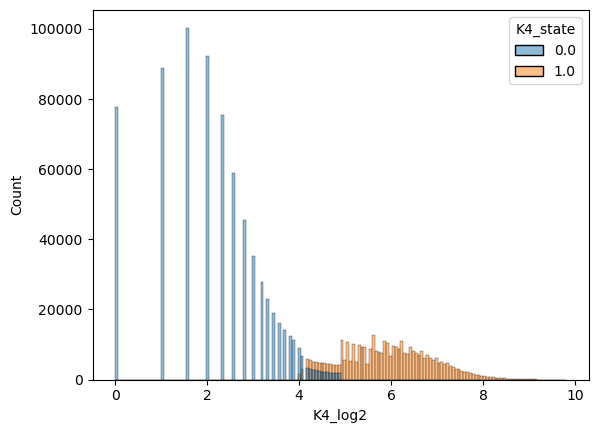

In [1612]:
#determine K4 marked promoters with one threshold per lineage

for ct in k4data['Lin'].unique():
    data = pd.array(k4data.loc[k4data['Lin']==ct,'K4_log2']).reshape(-1, 1)

    # Number of components (clusters) in the mixture
    num_components = 2

    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=num_components, random_state=42)
    gmm.fit(data)

    # Predict the cluster assignments for each data point
    labels = gmm.predict(data)

    # Get means and standard deviations for each component
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()


    k4data.loc[k4data['Lin']==ct,'K4_state']=labels

    if means[0]>means[1]:
        k4data.loc[((k4data['K4_state']==0)&(k4data['Lin']==ct)),'K4_state']=3
        k4data.loc[((k4data['K4_state']==1)&(k4data['Lin']==ct)),'K4_state']=0
        k4data.loc[((k4data['K4_state']==3)&(k4data['Lin']==ct)),'K4_state']=1
        
#plot result
sns.histplot(data=k4data, x='K4_log2', hue='K4_state', palette=['grey','#238B45'], legend=False)
plt.savefig('figures/fig4/K4_prom_binarise_hist.pdf', dpi='figure', format='pdf', bbox_inches='tight')

<AxesSubplot:xlabel='RNA_gene_log2', ylabel='Count'>

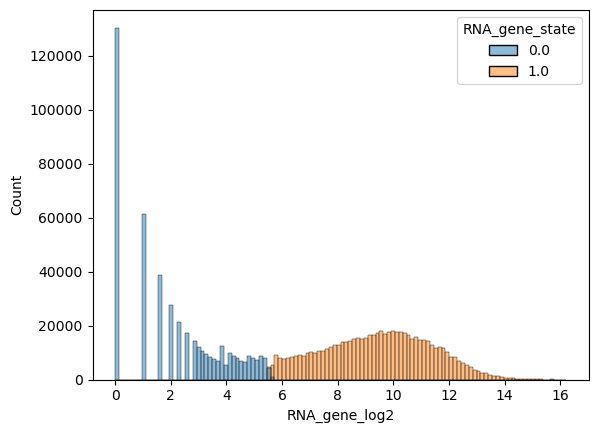

In [1613]:
#determine expressed genes with one threshold per lineage

for ct in k4data['Lin'].unique():
    data = pd.array(k4data.loc[k4data['Lin']==ct,'RNA_gene_log2']).reshape(-1, 1)

    # Number of components (clusters) in the mixture
    num_components = 2

    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=num_components, random_state=42)
    gmm.fit(data)

    # Predict the cluster assignments for each data point
    labels = gmm.predict(data)

    # Get means and standard deviations for each component
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()


    k4data.loc[k4data['Lin']==ct,'RNA_gene_state']=labels

    if means[0]>means[1]:
        k4data.loc[((k4data['RNA_gene_state']==0)&(k4data['Lin']==ct)),'RNA_gene_state']=3
        k4data.loc[((k4data['RNA_gene_state']==1)&(k4data['Lin']==ct)),'RNA_gene_state']=0
        k4data.loc[((k4data['RNA_gene_state']==3)&(k4data['Lin']==ct)),'RNA_gene_state']=1
        
#plot result
sns.histplot(data=k4data, x='RNA_gene_log2', hue='RNA_gene_state', palette=['grey','#D94801'], legend=False)
plt.savefig('figures/fig4/RNA_binarise_hist.pdf', dpi='figure', format='pdf', bbox_inches='tight')

<AxesSubplot:xlabel='RNA_genewise_max', ylabel='Count'>

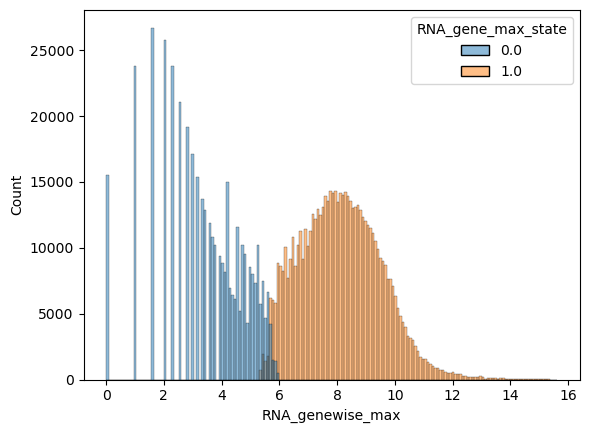

In [1614]:
#remove promoters overlapping gene end

k4data=k4data[~k4data['name'].isin(promstoremve)]

# determine promoter with max RNA counts per lin and rep and calculate relative promoter usage
agg_functions = {'gene':'first','RNA_sum': 'sum'}
tmp=k4data.groupby(['name']).aggregate(agg_functions)
tmp=tmp.reset_index()
max_prom=tmp.sort_values(by='RNA_sum', ascending=False).drop_duplicates(subset=['gene'], keep='first')['name']

tmp2=k4data.loc[k4data['name'].isin(max_prom),{'gene','Lin','rep','RNA_sum'}]
tmp2.columns=['Lin','gene','rep','RNA_genewise_max']
k4data=k4data.merge(tmp2, how='left', left_on=['gene','Lin','rep'], right_on=['gene','Lin','rep'])
k4data['RNA_rel']=(k4data['RNA_sum']/k4data['RNA_genewise_max'])*100



#import data from bed file creation about main annotated promoter
k4data=k4data.merge(final2.drop_duplicates(subset=['name'], keep='first')[{'name','prom_type'}], how='left', left_on=['name'], right_on=['name'])
k4data=k4data.merge(final2.drop_duplicates(subset=['gene'], keep='first')[{'gene','biotype'}], how='left', left_on=['gene'], right_on=['gene'])

# determine genes with high enough counts to determine dif prom usage

for ct in k4data['Lin'].unique():
    data = pd.array(np.log2(k4data.loc[k4data['Lin']==ct,'RNA_genewise_max']+1)).reshape(-1, 1)

    # Number of components (clusters) in the mixture
    num_components = 2

    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=num_components, random_state=42)
    gmm.fit(data)

    # Predict the cluster assignments for each data point
    labels = gmm.predict(data)

    # Get means and standard deviations for each component
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()


    k4data.loc[k4data['Lin']==ct,'RNA_gene_max_state']=labels

    if means[0]>means[1]:
        k4data.loc[((k4data['RNA_gene_max_state']==0)&(k4data['Lin']==ct)),'RNA_gene_max_state']=3
        k4data.loc[((k4data['RNA_gene_max_state']==1)&(k4data['Lin']==ct)),'RNA_gene_max_state']=0
        k4data.loc[((k4data['RNA_gene_max_state']==3)&(k4data['Lin']==ct)),'RNA_gene_max_state']=1
        
#relative expression of too low expressed genes is set to NaN to remove unreliable results
k4data.loc[k4data['RNA_gene_max_state']==0,'RNA_rel']=math.nan
        
#plot result
sns.histplot(x=np.log2(k4data['RNA_genewise_max']+1), hue=k4data['RNA_gene_max_state'], palette=['grey','#D94801'], legend=False)
plt.savefig('figures/fig4/RNA_prom_max_binarise_hist.pdf', dpi='figure', format='pdf', bbox_inches='tight')

In [26]:
#determine promoter wise K4me3 varaince

test=tss_anova_prom(k4data,'K4_sum')
test.columns=['K4_prom_p','K4_prom_min','K4_prom_max','K4_prom_mean','K4_prom_fold']
test['name']=test.index
k4data=test.merge(k4data, how='right', left_on=['name'], right_on=['name'])

k4data.loc[k4data['K4_prom_p']>1000,'K4_prom_p']=math.nan

In [27]:
#determine promoter wise RNA variance

testRNA=tss_anova_prom(k4data[((k4data['RNA_gene_max_state']==1)&(k4data['max_prom'].astype('int64')>1))], 'RNA_rel')
testRNA.columns=['RNA_prom_p','RNA_prom_min','RNA_prom_max','RNA_prom_mean','RNA_prom_fold']
testRNA=testRNA.reset_index()
k4data=k4data.merge(testRNA, how='left', left_on=['name'], right_on=['index'])

#promoters where all values are identical (eg 100%) will cause an infinite p value, we reset those to NaN as they are not significantly different
k4data.loc[k4data['RNA_prom_p']>1000,'RNA_prom_p']=math.nan

/home/p.zeller_cbs-niob.local/miniconda3/envs/TChIC_env/lib/python3.7/site-packages/scipy/stats/stats.py:3629: F_onewayBadInputSizesWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  warnings.warn(F_onewayBadInputSizesWarning(msg))
/home/p.zeller_cbs-niob.local/miniconda3/envs/TChIC_env/lib/python3.7/site-packages/pandas/core/arraylike.py:364: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [28]:
#determine gene wise RNA variance

testRNAgene=tss_anova_gene(k4data, 'RNA_gene_sum')
testRNAgene.columns=['RNA_gene_p','RNA_gene_min','RNA_gene_max','RNA_gene_mean','RNA_gene_fold']
testRNAgene=testRNAgene.reset_index()
k4data=k4data.merge(testRNAgene, how='left', left_on=['gene'], right_on=['index'])

k4data.loc[k4data['RNA_gene_p']>1000,'RNA_gene_p']=math.nan

In [40]:
#determine average K4state per promoter
agg_functions = {'K4_state': 'mean'}
tmp=k4data.groupby(['name','Lin']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['name','Lin','K4_state_avg_round']
tmp['K4_state_avg_round']=round(tmp['K4_state_avg_round'])
k4data=k4data.merge(tmp, how='left', left_on=['name','Lin'], right_on=['name','Lin'])

#determine max pos prom per gene
agg_functions = {'K4_state_avg_round': 'max'}
tmp=k4data.groupby(['gene','prom']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['gene','prom','K4maxperprom']

agg_functions = {'K4maxperprom': 'sum'}
tmp2=tmp.groupby(['gene']).aggregate(agg_functions)
tmp2=tmp2.reset_index()
tmp2.columns=['gene','K4_state_max_pos_prom_per_gene']

k4data=k4data.merge(tmp2, how='left', left_on=['gene'], right_on=['gene'])

#determine max K4 per gene
agg_functions = {'K4_sum': 'sum'}
tmp=k4data.groupby(['name']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['name','K4_prom_sum']
k4data=k4data.merge(tmp, how='left', left_on=['name'], right_on=['name'])

#determine average RNA per promoter
agg_functions = {'RNA_gene_state': 'mean'}
tmp=k4data.groupby(['gene','Lin']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['gene','Lin','RNA_state_avg_round']
tmp['RNA_state_avg_round']=round(tmp['RNA_state_avg_round'])
k4data=k4data.merge(tmp, how='left', left_on=['gene','Lin'], right_on=['gene','Lin'])

#determine average RNA state per promoter
agg_functions = {'RNA_prom_state': 'mean'}
tmp=k4data.groupby(['name','Lin']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['name','Lin','RNA_prom_state_avg_round']
#k4data=k4data.merge(tmp, how='left', left_on=['name'], right_on=['name'])
tmp['RNA_prom_state_avg_round']=round(tmp['RNA_prom_state_avg_round'])
k4data=k4data.merge(tmp, how='left', left_on=['name','Lin'], right_on=['name','Lin'])

In [120]:
k4data.to_csv('Fig4_incANOVA_full_table.csv',header=True, index=True, sep="\t")

In [80]:
K4_prom1_all=k4data[((k4data['biotype']=="protein_coding")&(k4data['prom']==1))].drop_duplicates(subset=['gene'], keep='first')['name']
K4_prom1_pos_ESC=k4data[((k4data['biotype']=="protein_coding")&(k4data['prom']==1)&(k4data['K4_state_avg_round']==1)&(k4data['Lin']=='ESC'))].drop_duplicates(subset=['gene'], keep='first')['name']
K4_prom1_pos_PLU=k4data[((k4data['biotype']=="protein_coding")&(k4data['prom']==1)&(k4data['K4_state_avg_round']==1)&(k4data['Lin']=='PLU'))].drop_duplicates(subset=['gene'], keep='first')['name']
K4_prom1_pos_ECT=k4data[((k4data['biotype']=="protein_coding")&(k4data['prom']==1)&(k4data['K4_state_avg_round']==1)&(k4data['Lin']=='ECT'))].drop_duplicates(subset=['gene'], keep='first')['name']
K4_prom1_pos_MES=k4data[((k4data['biotype']=="protein_coding")&(k4data['prom']==1)&(k4data['K4_state_avg_round']==1)&(k4data['Lin']=='MES'))].drop_duplicates(subset=['gene'], keep='first')['name']
K4_prom1_pos_END=k4data[((k4data['biotype']=="protein_coding")&(k4data['prom']==1)&(k4data['K4_state_avg_round']==1)&(k4data['Lin']=='END'))].drop_duplicates(subset=['gene'], keep='first')['name']

In [222]:


#1 annotated promoter: use that one
oneprom_genes=k4data[((k4data['biotype']=="protein_coding")&(k4data['max_prom']==1))].drop_duplicates(subset=['gene'], keep='first')['gene']
k4data[k4data['gene'].isin(oneprom_genes)].drop_duplicates(subset=['gene'], keep='first')
prom1=k4data[k4data['gene'].isin(oneprom_genes)].drop_duplicates(subset=['gene'], keep='first')[{'gene','name','prom_type','prom'}]


#multiple annotated but only 0 H3K4me3 pos promoter: use main annotated prom
geneswith0posprom=k4data[((k4data['biotype']=="protein_coding")&(k4data['max_prom']>1)&(k4data['K4_state_max_pos_prom_per_gene']==0))].drop_duplicates(subset=['gene'], keep='first')['gene']
prom2=k4data[((k4data['gene'].isin(geneswith0posprom))&(k4data['prom_type']=='main_an'))].drop_duplicates(subset=['gene'], keep='first')[{'gene','name','prom_type','prom'}]


#multiple annotated but only 1 H3K4me3 pos promoter: use H3K4me3 pos prom
geneswith2posprom_only1K4pos=k4data[((k4data['biotype']=="protein_coding")&(k4data['max_prom']>1)&(k4data['K4_state_max_pos_prom_per_gene']==1))].drop_duplicates(subset=['gene'], keep='first')['gene']
prom3=k4data[((k4data['gene'].isin(geneswith2posprom_only1K4pos))&(k4data['K4_state_avg_round']==1))].drop_duplicates(subset=['gene'], keep='first')[{'gene','name','prom_type','prom'}]


#multiple H3K4me3 pos promoters with multiple isoforms: use first H3K4me3 and RNA pos prom per Linage
geneswith2posprom=k4data[((k4data['biotype']=="protein_coding")&(k4data['max_prom']>1)&(k4data['K4_state_max_pos_prom_per_gene']>1))].drop_duplicates(subset=['gene'], keep='first')['gene']
geneswith2posprom_exp=k4data[((k4data['gene'].isin(geneswith2posprom))&(k4data['RNA_state_avg_round']==1))].drop_duplicates(subset=['gene'], keep='first')['gene']
geneswith2varprom_exp=k4data[((k4data['gene'].isin(geneswith2posprom_exp))&(k4data['K4_prom_p']>5)&(k4data['K4_prom_fold']>2.5))].drop_duplicates(subset=['gene'], keep='first')['gene']
geneswith2varprom_varexp=k4data[((k4data['gene'].isin(geneswith2varprom_exp))&(k4data['RNA_prom_p']>5)&(k4data['RNA_prom_fold']>2.5))].drop_duplicates(subset=['gene'], keep='first')['gene']
prom4=k4data[((k4data['gene'].isin(geneswith2varprom_varexp))&(k4data['K4_state_avg_round']==1)&(k4data['RNA_rel']>20))].sort_values(by='prom', ascending=True).drop_duplicates(subset=['gene','Lin'], keep='first').drop_duplicates(subset=['name'],keep='first')[{'gene','name','prom_type','prom'}]


#multiple H3K4me3 pos promoters with 1 expressed isoform: use first H3K4me3 and RNA rel >10 pos prom per gene
geneswith2posprom_stable_exp=geneswith2posprom_exp[~geneswith2posprom_exp.isin(geneswith2varprom_varexp)]
prom5a=k4data[((k4data['gene'].isin(geneswith2posprom_stable_exp))&(k4data['K4_state_avg_round']==1)&(k4data['RNA_rel']>10))].sort_values(by='prom', ascending=True).drop_duplicates(subset=['gene'], keep='first')[{'gene','name','prom_type','prom'}]
prom5agenes=k4data[((k4data['gene'].isin(geneswith2posprom_stable_exp))&(k4data['K4_state_avg_round']==1)&(k4data['RNA_rel']>10))].sort_values(by='prom', ascending=True).drop_duplicates(subset=['gene'], keep='first')['gene']
prom5bgenes=geneswith2posprom_stable_exp[~geneswith2posprom_stable_exp.isin(prom5agenes)] #genes with too low RNA per promoter use strongest H3K4me3 based annotation
prom5b=k4data[((k4data['gene'].isin(prom5bgenes))&(k4data['K4_state_avg_round']==1))].sort_values(by='K4_prom_sum', ascending=False).drop_duplicates(subset=['gene'], keep='first')[{'gene','name','prom_type','prom'}]


#multiple H3K4me3 pos promoters without expression: use prom with strongest H3K4me3 signal
geneswith2posprom_nonexp=geneswith2posprom[~geneswith2posprom.isin(geneswith2posprom_exp)]
prom6=k4data[((k4data['gene'].isin(geneswith2posprom_nonexp))&(k4data['K4_state_avg_round']==1))].sort_values(by='K4_prom_sum', ascending=False).drop_duplicates(subset=['gene'], keep='first')[{'gene','name','prom_type','prom'}]

prom_used_final=pd.concat([prom1,prom2,prom3,prom4,prom5a,prom5b,prom6])

prom_used_dif_genes=k4data.loc[k4data['gene'].isin(prom4['gene'].unique()),'name'].unique()


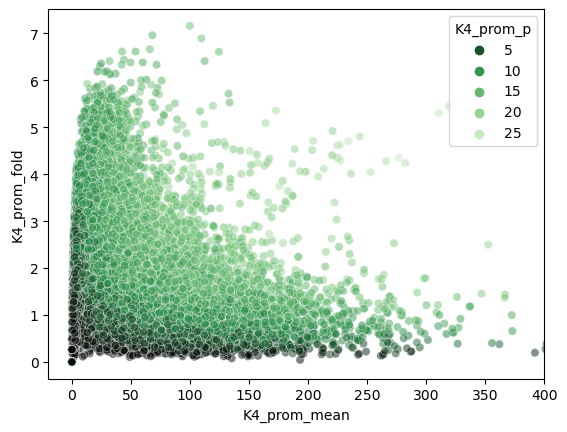

In [118]:
g=sns.scatterplot(data=k4data.drop_duplicates(subset=['name'], keep='first'), x='K4_prom_mean', y='K4_prom_fold', hue='K4_prom_p', alpha=0.5, palette=greens_r)
g.set_xlim(-20, 400)
plt.savefig('figures/fig4/H3K4me3_prom_fold_mean_p.pdf', dpi='figure', format='pdf', bbox_inches='tight')
plt.savefig('figures/fig4/H3K4me3_prom_fold_mean_p.png', dpi='figure', format='png', bbox_inches='tight')

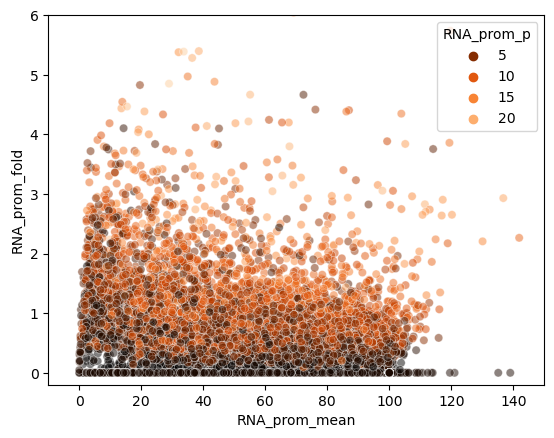

In [119]:
g=sns.scatterplot(data=k4data.drop_duplicates(subset=['name'], keep='first'), x='RNA_prom_mean', y='RNA_prom_fold', hue='RNA_prom_p', alpha=0.5, palette=oranges_r)
g.set_xlim(-10, 150)
g.set_ylim(-.2, 6)
plt.savefig('figures/fig4/RNA_prom_fold_mean_p.pdf', dpi='figure', format='pdf', bbox_inches='tight')
plt.savefig('figures/fig4/RNA_prom_fold_mean_p.png', dpi='figure', format='png', bbox_inches='tight')

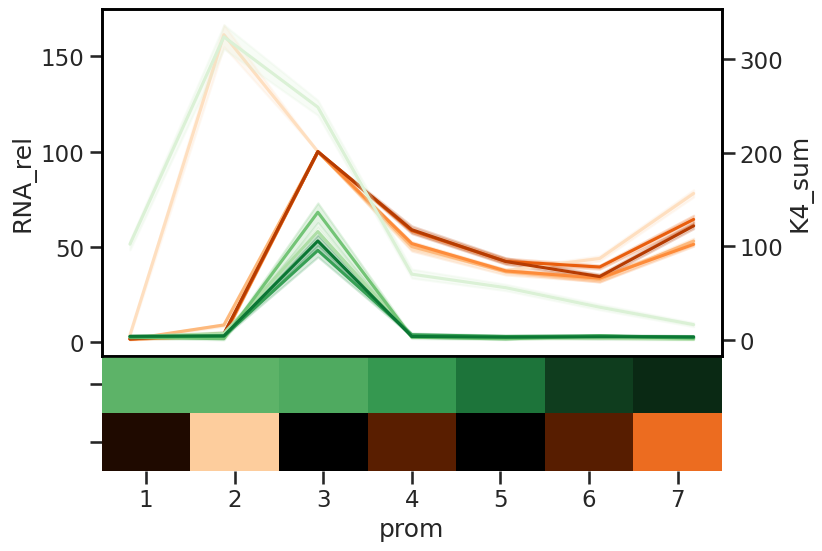

In [211]:
genename='Rbpj'


sns.set_context("talk", font_scale=1)
sns.set_style("whitegrid", {'axes.grid' : False, 'xtick.bottom': True,
 'ytick.left': True, 'axes.edgecolor': 'black'})

fig, axes = plt.subplots(3, 1, figsize=(8, 6), gridspec_kw={'hspace': 0 ,'height_ratios':(6,1,1)})
#plt.figure(figsize=(40,200))
axes = axes.flatten()
#fig.tight_layout(pad=0)



ax=sns.lineplot(data=k4data[k4data['gene']==genename], x="prom", y="RNA_rel", hue='Lin', palette="Oranges",ax=axes[0], legend=False)

ax=sns.lineplot(data=k4data[k4data['gene']==genename], x="prom", y="K4_sum", hue='Lin', palette="Greens",ax = axes[0].axes.twinx(), legend=False)

ax.tick_params(labelbottom=False, bottom=False)

#ax.tick_params(axis='x', rotation=90)
#ax.tick_params(labelbottom=False, bottom=False)
#axes[0].set_yscale('log')
#ax.set_ylim([0.00009,100])
#ax.invert_xaxis()
#ax.set(xlabel='',
#       ylabel='RNA mean counts',
#       title='')


#ax = sns.boxplot(data=plottable[plottable['mark']=='RNA'], x='quantile', y='values', orient='v', 
#    ax=axes[1], width=0.9,fliersize=0 , color=Orange)

plotdata=k4data.loc[k4data['gene']==genename, ['prom','K4_prom_p']].drop_duplicates(subset=['prom'], keep='first')
plotdata.set_index("prom", inplace=True)

ax1=sns.heatmap(plotdata.T, ax=axes[1], cmap=greens_r, vmin=5, vmax=20, cbar=False)
axes[1].tick_params(labelbottom=False, bottom=False)
axes[1].tick_params(labelleft=False)


plotdata=k4data.loc[k4data['gene']==genename, ['prom','RNA_prom_p']].drop_duplicates(subset=['prom'], keep='first')
plotdata.set_index("prom", inplace=True)

ax1=sns.heatmap(plotdata.T, ax=axes[2], cmap=oranges_r, vmin=5, vmax=20, cbar=False)
#axes[2].tick_params(labelbottom=False, bottom=False)
axes[2].tick_params(labelleft=False)





plt.savefig('figures/fig4/Rbpj_detail_plot.pdf', dpi='figure', format='pdf', bbox_inches='tight')



In [224]:
final[final['name'].isin(prom_used_final['name'])].to_csv('20240114_mouse_selected_TSS.bed',header=None, index=None, sep="\t")
final[final['biotype']=='protein_coding'].to_csv('20240114_mouse_all_protcode_TSS.bed',header=None, index=None, sep="\t")
K4scdata[prom_used_final['name']].to_csv('20240114_H3K4me3_sc_selected.bed',header=True, index=True, sep="\t")
K27scdata[prom_used_final['name']].to_csv('20240114_H3K27me3_sc_selected.bed',header=True, index=True, sep="\t")
K4scdata[prom_used_dif_genes].to_csv('20240114_H3K4me3_sc_selected_dyn_TSS.bed',header=True, index=True, sep="\t")
K27scdata[prom_used_dif_genes].to_csv('20240114_H3K27me3_sc_selected_dyn_TSS.bed',header=True, index=True, sep="\t")

In [1458]:
# not used

# determine the number of annotated promoter, if the gene is ever expressed and any of its promoters ever K4 marked
agg_functions = {'gene': 'first', 'prom': 'max', 'RNA_gene_state': 'max', 'K4_state': 'max'}
tmp=k4data.groupby(['gene']).aggregate(agg_functions)
tmp.columns=['gene','max_prom','ever_expressed','ever_K4']
tmp=tmp.reset_index(drop=True)
k4data=k4data.merge(tmp, how='inner', left_on=['gene'], right_on=['gene'])

# determine if a gene is ever expressed or K4 marked in the each linage seperate
agg_functions = {'gene': 'first', 'Lin':'first', 'RNA_gene_state': 'max', 'K4_state': 'max'}
tmp=k4data.groupby(['gene','Lin']).aggregate(agg_functions)
tmp.columns=['gene','Lin','Lin_expressed','Lin_K4']
tmp=tmp.reset_index(drop=True)
k4data=k4data.merge(tmp, how='inner', left_on=['gene','Lin'], right_on=['gene','Lin'])

#deterime number of different K4 marked promotors per gene
countusedprom=k4data[k4data['K4_state']==1]
countusedprom=countusedprom.drop_duplicates(subset=['name'], keep='first')

agg_functions = {'K4_state': 'count'}
tmp=countusedprom.groupby(['gene']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['gene','pos_prom_count']
k4data=k4data.merge(tmp, how='left', left_on=['gene'], right_on=['gene'])

#determine if a promoter is ever K4 marked
agg_functions = {'K4_state': 'max'}
tmp=k4data.groupby(['name']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['name','prom_ever_K4']
k4data=k4data.merge(tmp, how='left', left_on=['name'], right_on=['name'])

#determine average K4state per promoter
agg_functions = {'K4_state': 'mean'}
tmp=k4data.groupby(['name']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['name','K4_state_avg']
k4data=k4data.merge(tmp, how='left', left_on=['name'], right_on=['name'])

#determine max_average K4state per gene and linage
tmp2=k4data.copy()
tmp2=tmp2.sort_values(by='K4_state_avg_round', ascending=False).drop_duplicates(subset=['name','Lin'], keep='first')
agg_functions = {'K4_state_avg_round': 'sum'}
tmp=tmp2.groupby(['gene','Lin']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['gene','Lin','K4_state_gene_max_sum']
k4data=k4data.merge(tmp, how='left', left_on=['gene','Lin'], right_on=['gene','Lin'])

#determine max_average K4state per gene

agg_functions = {'K4_state_avg_round': 'max'}
tmp=k4data.groupby(['gene','Lin']).aggregate(agg_functions)
tmp=tmp.reset_index()
tmp.columns=['gene','Lin','K4_state_gene_max']
k4data=k4data.merge(tmp, how='left', left_on=['gene','Lin'], right_on=['gene','Lin'])

In [ ]:
#determine expressed promoters with one threshold per lineage

for ct in k4data['Lin'].unique():
    data = pd.array(k4data.loc[k4data['Lin']==ct,'RNA_log2']).reshape(-1, 1)

    # Number of components (clusters) in the mixture
    num_components = 2

    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=num_components, random_state=42)
    gmm.fit(data)

    # Predict the cluster assignments for each data point
    labels = gmm.predict(data)

    # Get means and standard deviations for each component
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()


    k4data.loc[k4data['Lin']==ct,'RNA_prom_state']=labels

    if means[0]>means[1]:
        k4data.loc[((k4data['RNA_prom_state']==0)&(k4data['Lin']==ct)),'RNA_prom_state']=3
        k4data.loc[((k4data['RNA_prom_state']==1)&(k4data['Lin']==ct)),'RNA_prom_state']=0
        k4data.loc[((k4data['RNA_prom_state']==3)&(k4data['Lin']==ct)),'RNA_prom_state']=1
        
#plot result
sns.histplot(data=k4data, x='RNA_log2', hue='RNA_prom_state', palette=['grey','#D94801'], legend=False)